# Importando as Bilbiotecas

In [37]:
# Manipulação de dados
import re
import numpy as np
import pandas as pd

# Visualização
import matplotlib.pyplot as plt

# NLP - NLTK
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import SnowballStemmer

# Recursos do NLTK
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)
nltk.download("rslp", quiet=True)

# Preparação e validação
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold,
    learning_curve
)

# Representação textual
from sklearn.feature_extraction.text import CountVectorizer

# Modelos
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

# Pipeline
from sklearn.pipeline import Pipeline

# Avaliação
from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


## Leitura da Base de Dados

In [2]:
dados = pd.read_csv("../data/dados_spam.csv", index_col=0)
dados.head()

,categoria,texto
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


# 1. Pré-Processamento dos Dados

### 1.1 Limpeza e Normalização do Texto

In [3]:
ABBREVIATIONS = {
    # Conversa / SMS
    "pls": "please", "plz": "please", "thx": "thanks", "ty": "thank you", "u": "you", "ur": "your", "r": "are",
    "ya": "you", "msg": "message", "txt": "text", "idk": "i do not know", "imo": "in my opinion", "imho": "in my humble opinion",
    "asap": "as soon as possible", "rn": "right now", "btw": "by the way", "fyi": "for your information", "brb": "be right back",
    "ttyl": "talk to you later", "lol": "laughing out loud", "omg": "oh my god",
    # Tempo / urgência
    "tmr": "tomorrow", "tmrw": "tomorrow", "tdy": "today", "2day": "today", "2nite": "tonight", "nite": "night", "wk": "week",
    "wks": "weeks", "hr": "hour", "hrs": "hours", "min": "minute", "mins": "minutes",
    # Financeiro
    "acct": "account", "accts": "accounts", "txn": "transaction", "txns": "transactions", "transac": "transaction", "amt": "amount",
    "bal": "balance", "avl": "available", "stmt": "statement", "stmts": "statements", "ref": "reference",
    # Pagamentos
    "pymt": "payment", "pymts": "payments", "pmt": "payment", "pmts": "payments", "paymt": "payment",
    # Promoções / spam
    "promo": "promotion", "promos": "promotions", "disc": "discount", "pct": "percent", "exp": "expires", "expd": "expired",
    "offer": "offer", "offers": "offers",
    # Contato
    "ph": "phone", "tel": "telephone", "mob": "mobile", "addr": "address", "info": "information",
}

In [4]:
def limpar_texto(texto):

    # 1. Lowercase
    texto = texto.lower()
    # 2. Remover HTML
    texto = re.sub(r'<[^>]+>', " ", texto)
    # 3. Remover URLs
    texto = re.sub(r'https?://\S+|www\.\S+', " ", texto)
    # 4. Remover E-mails
    texto = re.sub(r'\b[\w\.-]+@[\w\.-]+\.\w+\b', " ", texto)
    # 5. Remover telefones
    texto = re.sub(r'\+?\d[\d\s\-\(\)]{7,}\d', " ", texto)
    # 6. Remover Dinheiro
    texto = re.sub(r'(r\$|\$|€|£)\s?\d+(?:[.,]\d+)?', " ", texto)
    # 7. Substituindo as abreviações
    palavras = [ABBREVIATIONS.get(p,p) for p in texto.split()]
    texto = " ".join(palavras)
    # 8. Remove caracteres indesejados
    texto = re.sub(r'[^a-záàâãéêèíìîóôõöúùûüç\s.,!?]', " ", texto)
    # 9. Normaliza espaços
    texto = re.sub(r'\s+', " ", texto)

    return texto

In [5]:
df_teste = dados.copy()

df_teste["texto_limpo"] = df_teste["texto"].apply(limpar_texto)

df_teste[["texto", "texto_limpo"]].head()

,texto,texto_limpo
0,"Go until jurong point, crazy.. Available only ...","go until jurong point, crazy.. available only ..."
1,Ok lar... Joking wif u oni...,ok lar... joking wif you oni...
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final ...
3,U dun say so early hor... U c already then say...,you dun say so early hor... you c already then...
4,"Nah I don't think he goes to usf, he lives aro...","nah i don t think he goes to usf, he lives aro..."


### 1.2 Tokenização

In [6]:
def tokenizar(texto):

    return word_tokenize(texto, language="english")

In [7]:
df_teste["texto_token"] = df_teste["texto_limpo"].apply(tokenizar)

df_teste[["texto_limpo", "texto_token"]].head()

,texto_limpo,texto_token
0,"go until jurong point, crazy.. available only ...","[go, until, jurong, point, ,, crazy, .., avail..."
1,ok lar... joking wif you oni...,"[ok, lar, ..., joking, wif, you, oni, ...]"
2,free entry in a wkly comp to win fa cup final ...,"[free, entry, in, a, wkly, comp, to, win, fa, ..."
3,you dun say so early hor... you c already then...,"[you, dun, say, so, early, hor, ..., you, c, a..."
4,"nah i don t think he goes to usf, he lives aro...","[nah, i, don, t, think, he, goes, to, usf, ,, ..."


In [8]:
# Pegando 1 exemplo
print(df_teste["texto_token"][0])

['go', 'until', 'jurong', 'point', ',', 'crazy', '..', 'available', 'only', 'in', 'bugis', 'n', 'great', 'world', 'la', 'e', 'buffet', '...', 'cine', 'there', 'got', 'amore', 'wat', '...']


### 1.3 Removendo StopWords

In [9]:
STOP_WORDS = set(stopwords.words("english"))

NEGACAO = {
    "no", "not", "nor", "never", "neither",
    "none", "nobody", "nothing", "nowhere",
    "cannot", "without",

    # Contrações negativas
    "don't", "doesn't", "didn't",
    "isn't", "aren't", "wasn't", "weren't",
    "haven't", "hasn't", "hadn't",
    "won't", "wouldn't", "can't", "couldn't",
    "shouldn't", "mustn't", "needn't",
}

STOP_WORDS_EN = STOP_WORDS - NEGACAO

In [10]:
def stop_words(tokens):
    resultado = []
    for token in tokens:
        if (token.isalpha() and token not in STOP_WORDS_EN):
            resultado.append(token)
    
    return resultado

In [11]:
df_teste["texto_stop_word"] = df_teste["texto_token"].apply(stop_words)

df_teste[["texto_token", "texto_stop_word"]].head()

,texto_token,texto_stop_word
0,"[go, until, jurong, point, ,, crazy, .., avail...","[go, jurong, point, crazy, available, bugis, n..."
1,"[ok, lar, ..., joking, wif, you, oni, ...]","[ok, lar, joking, wif, oni]"
2,"[free, entry, in, a, wkly, comp, to, win, fa, ...","[free, entry, wkly, comp, win, fa, cup, final,..."
3,"[you, dun, say, so, early, hor, ..., you, c, a...","[dun, say, early, hor, c, already, say]"
4,"[nah, i, don, t, think, he, goes, to, usf, ,, ...","[nah, think, goes, usf, lives, around, though]"


In [12]:
# mostrando exemplos
print(df_teste["texto_token"][0])
print(df_teste["texto_stop_word"][0])

['go', 'until', 'jurong', 'point', ',', 'crazy', '..', 'available', 'only', 'in', 'bugis', 'n', 'great', 'world', 'la', 'e', 'buffet', '...', 'cine', 'there', 'got', 'amore', 'wat', '...']
['go', 'jurong', 'point', 'crazy', 'available', 'bugis', 'n', 'great', 'world', 'la', 'e', 'buffet', 'cine', 'got', 'amore', 'wat']


### 1.4 Stemmer

In [13]:
stemmer = SnowballStemmer("english")

def aplicar_stemmer(tokens):
    resultado =[]
    for token in tokens:
        resultado.append(stemmer.stem(token))

    return resultado

In [14]:
df_teste["texto_stemmer"] = df_teste["texto_stop_word"].apply(aplicar_stemmer)

df_teste[["texto_stop_word", "texto_stemmer"]].head()

,texto_stop_word,texto_stemmer
0,"[go, jurong, point, crazy, available, bugis, n...","[go, jurong, point, crazi, avail, bugi, n, gre..."
1,"[ok, lar, joking, wif, oni]","[ok, lar, joke, wif, oni]"
2,"[free, entry, wkly, comp, win, fa, cup, final,...","[free, entri, wkli, comp, win, fa, cup, final,..."
3,"[dun, say, early, hor, c, already, say]","[dun, say, earli, hor, c, alreadi, say]"
4,"[nah, think, goes, usf, lives, around, though]","[nah, think, goe, usf, live, around, though]"


In [15]:
# mostrando exemplos
print(df_teste["texto_stop_word"][0])
print(df_teste["texto_stemmer"][0])

['go', 'jurong', 'point', 'crazy', 'available', 'bugis', 'n', 'great', 'world', 'la', 'e', 'buffet', 'cine', 'got', 'amore', 'wat']
['go', 'jurong', 'point', 'crazi', 'avail', 'bugi', 'n', 'great', 'world', 'la', 'e', 'buffet', 'cine', 'got', 'amor', 'wat']


### 1.5 Aplicando Pipeline Completo

In [16]:
def pipeline_completo(texto):

    texto = limpar_texto(texto)
    token = tokenizar(texto)
    stop_word = stop_words(token)
    stemmer = aplicar_stemmer(stop_word)

    return " ".join(stemmer)

In [17]:
dados["texto_tratado"] = dados["texto"].apply(pipeline_completo)
dados.head()

,categoria,texto,texto_tratado
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,ham,Ok lar... Joking wif u oni...,ok lar joke wif oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entri wkli comp win fa cup final tkts st ...
3,ham,U dun say so early hor... U c already then say...,dun say earli hor c alreadi say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah think goe usf live around though


# 2. Preparação dos Dados

### 2.1 Divisão dos Dados

In [18]:
X = dados["texto_tratado"]
y = dados["categoria"]

In [19]:
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

print(f"Total Treino -> {len(X_treino)}")
print(f"Total Teste -> {len(X_teste)}")

Total Treino -> 4459
Total Teste -> 1115


### 2.2 Vetorização com BoW + Ngram

In [20]:
vectorizer = CountVectorizer(
    lowercase=True,
    ngram_range=(1,2),
    min_df=5,
    max_df=0.85,
    max_features=10000
)

# 3. Modelos NLP

### 3.1 Modelo Naive Bayes

In [21]:
pipeline_nb = Pipeline([
    ("vectorizer", vectorizer),
    ("modelo_nb", MultinomialNB(alpha=1.0))
])

pipeline_nb.fit(X_treino, y_treino)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('vectorizer', ...), ('modelo_nb', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[<U4](2,)","['ham','spam']"
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentword n-grams or char n-grams to be extracted. All values of n suchsuch that min_n <= n <= max_n will be used. For example an``ngram_range`` of ``(1, 1)`` means only unigrams, ``(1, 2)`` meansunigrams and bigrams, and ``(2, 2)`` means only bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"max_df max_df: float in range [0.0, 1.0] or int, default=1.0When building the vocabulary ignore terms that have a documentfrequency strictly higher than the given threshold (corpus-specificstop words).If float, the parameter represents a proportion of documents, integerabsolute counts.This parameter is ignored if vocabulary is not None.",0.85
,"min_df min_df: float in range [0.0, 1.0] or int, default=1When building the vocabulary ignore terms that have a documentfrequency strictly lower than the given threshold. This value is alsocalled cut-off in the literature.If float, the parameter represents a proportion of documents, integerabsolute counts.This parameter is ignored if vocabulary is not None.",5
,"max_features max_features: int, default=NoneIf not None, build a vocabulary that only consider the top`max_features` ordered by term frequency across the corpus.Otherwise, all features are used.This parameter is ignored if vocabulary is not None.",10000
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'


In [22]:
previsao_nb = pipeline_nb.predict(X_teste)

print("=== RESULTADOS MODELO NAIVE BAYES ===")
print(classification_report(y_teste, previsao_nb))

=== RESULTADOS MODELO NAIVE BAYES ===
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       966
        spam       0.96      0.93      0.94       149

    accuracy                           0.98      1115
   macro avg       0.97      0.96      0.97      1115
weighted avg       0.98      0.98      0.98      1115



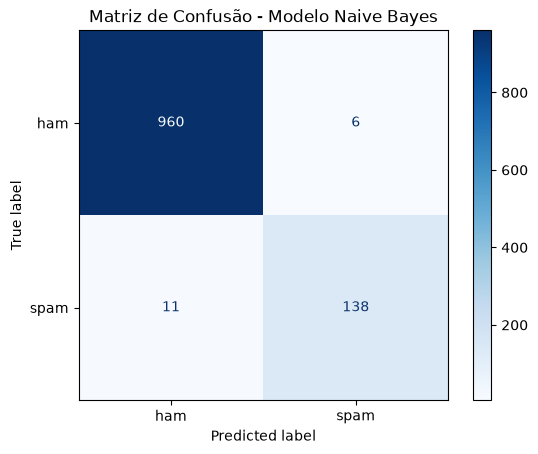

In [23]:
ConfusionMatrixDisplay.from_estimator(pipeline_nb, X_teste, y_teste, cmap="Blues")
plt.title("Matriz de Confusão - Modelo Naive Bayes")
plt.show()

### 3.2 Modelo Regressão Logística

In [24]:
pipeline_rl = Pipeline([
    ("vectorizer", vectorizer),
    ("modelo_rl", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
])

pipeline_rl.fit(X_treino, y_treino)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('vectorizer', ...), ('modelo_rl', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['ham','spam']"
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentword n-grams or char n-grams to be extracted. All values of n suchsuch that min_n <= n <= max_n will be used. For example an``ngram_range`` of ``(1, 1)`` means only unigrams, ``(1, 2)`` meansunigrams and bigrams, and ``(2, 2)`` means only bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"max_df max_df: float in range [0.0, 1.0] or int, default=1.0When building the vocabulary ignore terms that have a documentfrequency strictly higher than the given threshold (corpus-specificstop words).If float, the parameter represents a proportion of documents, integerabsolute counts.This parameter is ignored if vocabulary is not None.",0.85
,"min_df min_df: float in range [0.0, 1.0] or int, default=1When building the vocabulary ignore terms that have a documentfrequency strictly lower than the given threshold. This value is alsocalled cut-off in the literature.If float, the parameter represents a proportion of documents, integerabsolute counts.This parameter is ignored if vocabulary is not None.",5
,"max_features max_features: int, default=NoneIf not None, build a vocabulary that only consider the top`max_features` ordered by term frequency across the corpus.Otherwise, all features are used.This parameter is ignored if vocabulary is not None.",10000
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'


In [25]:
previsao_rl = pipeline_rl.predict(X_teste)

print("=== RESULTADOS MODELO REGRESSÃO LOGÍSTICA ===")
print(classification_report(y_teste, previsao_rl))

=== RESULTADOS MODELO REGRESSÃO LOGÍSTICA ===
              precision    recall  f1-score   support

         ham       0.99      1.00      0.99       966
        spam       0.98      0.93      0.96       149

    accuracy                           0.99      1115
   macro avg       0.98      0.96      0.97      1115
weighted avg       0.99      0.99      0.99      1115



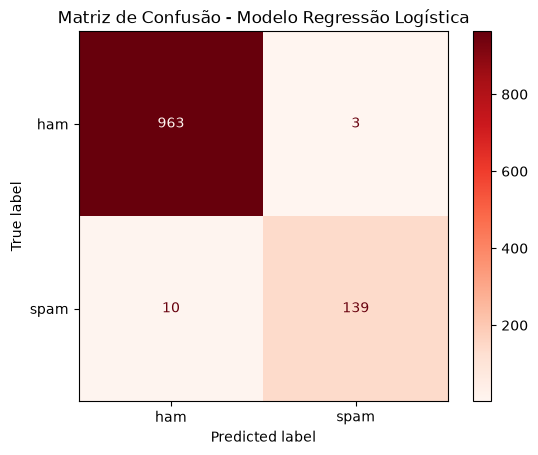

In [26]:
ConfusionMatrixDisplay.from_estimator(pipeline_rl, X_teste, y_teste, cmap="Reds")
plt.title("Matriz de Confusão - Modelo Regressão Logística")
plt.show()

### 3.3 Modelo SVM (Support Vector Machine)

In [27]:
pipeline_svm = Pipeline([
    ("vectorizer", vectorizer),
    ("modelo_svm", LinearSVC(class_weight="balanced", random_state=42))
])

pipeline_svm.fit(X_treino, y_treino)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('vectorizer', ...), ('modelo_svm', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['ham','spam']"
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentword n-grams or char n-grams to be extracted. All values of n suchsuch that min_n <= n <= max_n will be used. For example an``ngram_range`` of ``(1, 1)`` means only unigrams, ``(1, 2)`` meansunigrams and bigrams, and ``(2, 2)`` means only bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"max_df max_df: float in range [0.0, 1.0] or int, default=1.0When building the vocabulary ignore terms that have a documentfrequency strictly higher than the given threshold (corpus-specificstop words).If float, the parameter represents a proportion of documents, integerabsolute counts.This parameter is ignored if vocabulary is not None.",0.85
,"min_df min_df: float in range [0.0, 1.0] or int, default=1When building the vocabulary ignore terms that have a documentfrequency strictly lower than the given threshold. This value is alsocalled cut-off in the literature.If float, the parameter represents a proportion of documents, integerabsolute counts.This parameter is ignored if vocabulary is not None.",5
,"max_features max_features: int, default=NoneIf not None, build a vocabulary that only consider the top`max_features` ordered by term frequency across the corpus.Otherwise, all features are used.This parameter is ignored if vocabulary is not None.",10000
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'


In [28]:
previsao_svm = pipeline_svm.predict(X_teste)

print("=== RESULTADOS MODELO SVM ===")
print(classification_report(y_teste, previsao_svm))

=== RESULTADOS MODELO SVM ===
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       966
        spam       0.97      0.93      0.95       149

    accuracy                           0.99      1115
   macro avg       0.98      0.96      0.97      1115
weighted avg       0.99      0.99      0.99      1115



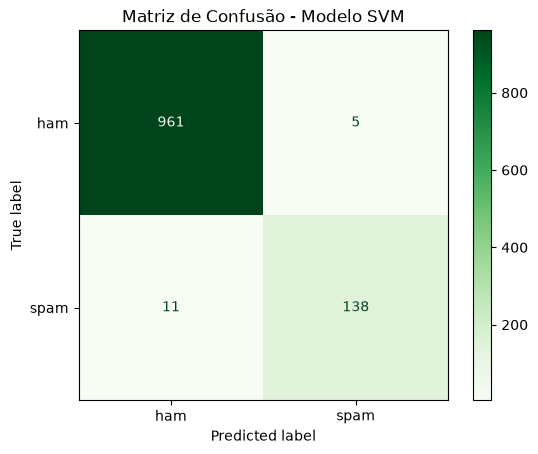

In [29]:
ConfusionMatrixDisplay.from_estimator(pipeline_svm, X_teste, y_teste, cmap="Greens")
plt.title("Matriz de Confusão - Modelo SVM")
plt.show()

# 4. Otimização dos Modelos com GridSearchCV

### 4.1 Otimização Modelo Naive Bayes

In [30]:
pipeline_nb = Pipeline([
    ("vectorizer", vectorizer),
    ("modelo_nb", MultinomialNB())
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid_nb = {
    "modelo_nb__alpha":[0.01, 0.1, 0.5, 1.0, 2.0],
    "modelo_nb__fit_prior": [True, False]
}

grid_nb = GridSearchCV(
    estimator=pipeline_nb,
    param_grid=param_grid_nb,
    scoring="f1_macro",
    cv=cv
)

grid_nb.fit(X_treino, y_treino)

print(f"Melhor Score -> {grid_nb.best_score_}")
print(f"Melhores Hiperparametros -> {grid_nb.best_params_}")

Melhor Score -> 0.9523101319305098
Melhores Hiperparametros -> {'modelo_nb__alpha': 0.1, 'modelo_nb__fit_prior': True}


### 4.2 Otimização Modelo Regressão Logística

In [31]:
pipeline_rl = Pipeline([
    ("vectorizer", vectorizer),
    ("modelo_rl", LogisticRegression(class_weight="balanced", random_state=42))
])

param_grid_rl = {
    "modelo_rl__C": [0.01, 0.1, 0.5, 1.0, 2.0],
    "modelo_rl__max_iter": [1000, 2000, 3000]
}

grid_rl = GridSearchCV(
    estimator= pipeline_rl,
    param_grid=param_grid_rl,
    scoring="f1_macro",
    cv=cv
)

grid_rl.fit(X_treino, y_treino)

print(f"Melhor Score -> {grid_rl.best_score_}")
print(f"Melhores Hiperparametros -> {grid_rl.best_params_}")

Melhor Score -> 0.9523270413305749
Melhores Hiperparametros -> {'modelo_rl__C': 1.0, 'modelo_rl__max_iter': 1000}


### 4.3 Otimização Modelo SVM

In [32]:
pipeline_svm = Pipeline([
    ("vectorizer", vectorizer),
    ("modelo_svm", LinearSVC(class_weight="balanced", random_state=42))
])

param_grid_svm = {
    "modelo_svm__C": [0.01, 0.1, 0.5, 1.0, 2.0]
}

grid_svm = GridSearchCV(
    estimator=pipeline_svm,
    param_grid=param_grid_svm,
    cv=cv,
    scoring="f1_macro"
)

grid_svm.fit(X_treino, y_treino)

print(f"Melhor Score -> {grid_svm.best_score_}")
print(f"Melhores Hiperparâmetros -> {grid_svm.best_params_}")

Melhor Score -> 0.9512626965548068
Melhores Hiperparâmetros -> {'modelo_svm__C': 1.0}


# 5. Comparação dos Modelos Otimizados

In [33]:
modelos_otimizados = {
    "Naive Bayes Otimizado": grid_nb.best_estimator_,
    "Regressão Logística Otimizado": grid_rl.best_estimator_,
    "SVM Otimizado": grid_svm.best_estimator_
}

for nome, modelo in modelos_otimizados.items():
    previsao = modelo.predict(X_teste)

    print(f"[MODELO] -> {nome}")
    print(classification_report(y_teste, previsao))
    print("-"*60)

[MODELO] -> Naive Bayes Otimizado
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       966
        spam       0.94      0.92      0.93       149

    accuracy                           0.98      1115
   macro avg       0.97      0.96      0.96      1115
weighted avg       0.98      0.98      0.98      1115

------------------------------------------------------------
[MODELO] -> Regressão Logística Otimizado
              precision    recall  f1-score   support

         ham       0.99      1.00      0.99       966
        spam       0.98      0.93      0.96       149

    accuracy                           0.99      1115
   macro avg       0.98      0.96      0.97      1115
weighted avg       0.99      0.99      0.99      1115

------------------------------------------------------------
[MODELO] -> SVM Otimizado
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       966
        spam 

In [34]:
modelo_nb_otimizado = grid_nb.best_estimator_
modelo_rl_otimizado = grid_rl.best_estimator_
modelo_svm_otimizado = grid_svm.best_estimator_

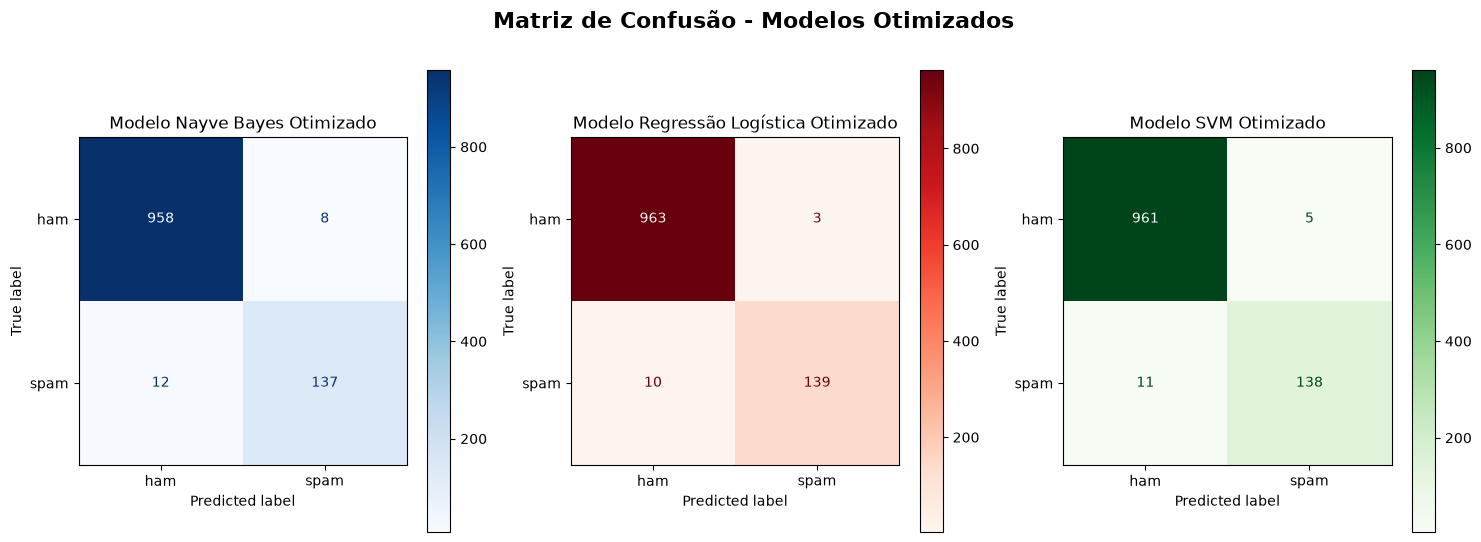

In [35]:
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

ConfusionMatrixDisplay.from_estimator(modelo_nb_otimizado, X_teste, y_teste, cmap="Blues", ax=ax[0])
ax[0].set_title("Modelo Nayve Bayes Otimizado")

ConfusionMatrixDisplay.from_estimator(modelo_rl_otimizado, X_teste, y_teste, cmap="Reds", ax=ax[1])
ax[1].set_title("Modelo Regressão Logística Otimizado")

ConfusionMatrixDisplay.from_estimator(modelo_svm_otimizado, X_teste, y_teste, cmap="Greens", ax=ax[2])
ax[2].set_title("Modelo SVM Otimizado")

plt.suptitle("Matriz de Confusão - Modelos Otimizados", fontsize=16, fontweight="bold")
plt.show()

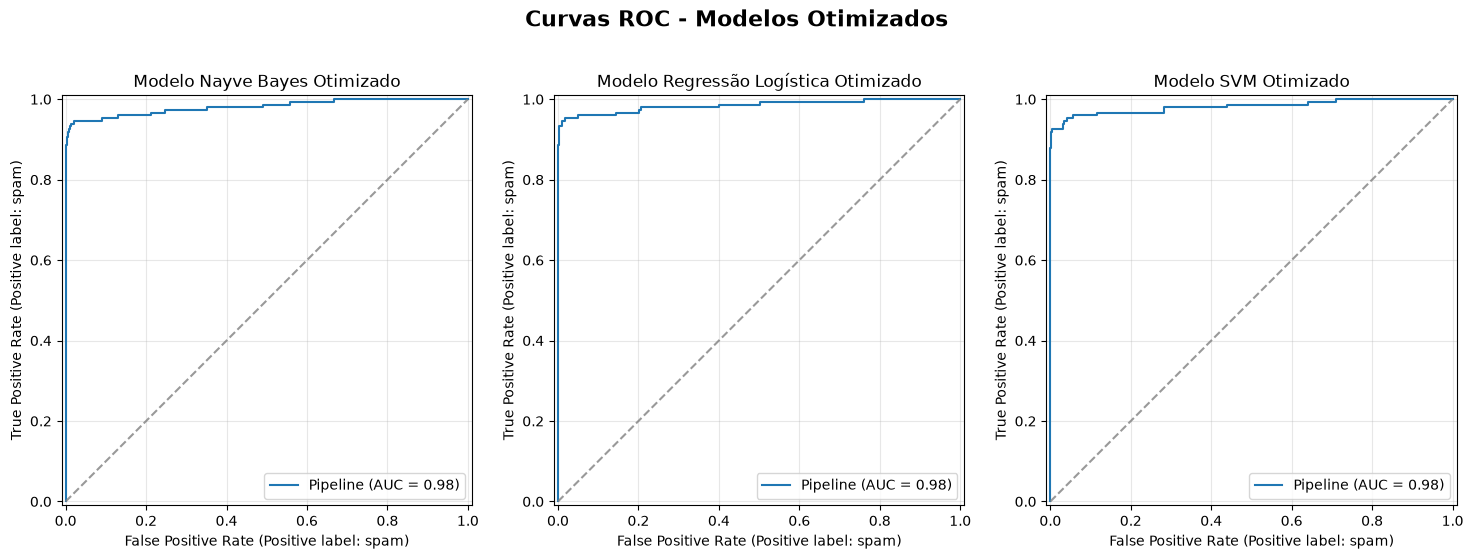

In [38]:
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

RocCurveDisplay.from_estimator(modelo_nb_otimizado, X_teste, y_teste, ax=ax[0])
ax[0].plot([0, 1], [0, 1], linestyle="--", color="gray", alpha=0.8)
ax[0].set_title("Modelo Nayve Bayes Otimizado")
ax[0].grid(alpha=0.3)

RocCurveDisplay.from_estimator(modelo_rl_otimizado, X_teste, y_teste, ax=ax[1])
ax[1].plot([0, 1], [0, 1], linestyle="--", color="gray", alpha=0.8)
ax[1].set_title("Modelo Regressão Logística Otimizado")
ax[1].grid(alpha=0.3)

RocCurveDisplay.from_estimator(modelo_svm_otimizado, X_teste, y_teste, ax=ax[2])
ax[2].plot([0, 1], [0, 1], linestyle="--", color="gray", alpha=0.8)
ax[2].set_title("Modelo SVM Otimizado")
ax[2].grid(alpha=0.3)

plt.suptitle("Curvas ROC - Modelos Otimizados", fontsize=16, fontweight="bold")
plt.show()

# 6. Curva de Aprendizado Modelo Final

In [39]:
train_sizes, train_score, val_score = learning_curve(
    estimator=modelo_rl_otimizado,
    X=X_treino,
    y=y_treino,
    train_sizes=np.linspace(0.1, 1, 10),
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1
)

train_mean = train_score.mean(axis=1)
train_std = train_score.std(axis=1)

val_mean = val_score.mean(axis=1)
val_std = val_score.std(axis=1)

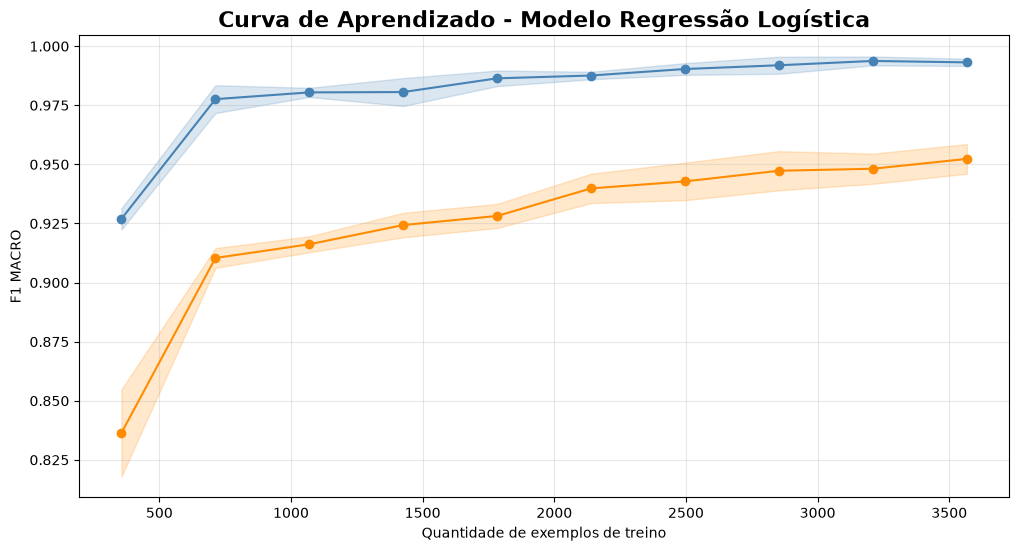

In [40]:
plt.figure(figsize=(12, 6))

# Curva de Treino
plt.plot(train_sizes, train_mean, marker="o", label="Treino", color="steelblue")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, color="steelblue", alpha=0.2)

# Curva de Teste
plt.plot(train_sizes, val_mean, marker="o", label="Teste", color="darkorange")
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, color="darkorange", alpha=0.2)

plt.title("Curva de Aprendizado - Modelo Regressão Logística", fontsize=16, fontweight="bold")
plt.xlabel("Quantidade de exemplos de treino")
plt.ylabel("F1 MACRO")
plt.grid(alpha=0.3)
plt.show()

In [42]:
gap_final = train_mean[-1] - val_mean[-1]

print(f"Valor Final Treino -> {train_mean[-1]:.3f}")
print(f"Valor Final Teste -> {val_mean[-1]:.3f}")
print(f"GAP FINAL -> {gap_final:.3f}")

Valor Final Treino -> 0.993
Valor Final Teste -> 0.952
GAP FINAL -> 0.041


# 7. Avaliação Final do Conjunto de Teste

In [43]:
modelo_final = grid_rl.best_estimator_

previsao_final = modelo_final.predict(X_teste)

In [44]:
print("=== AVALIAÇÃO FINAL ===")
print(classification_report(y_teste, previsao_final))

=== AVALIAÇÃO FINAL ===
              precision    recall  f1-score   support

         ham       0.99      1.00      0.99       966
        spam       0.98      0.93      0.96       149

    accuracy                           0.99      1115
   macro avg       0.98      0.96      0.97      1115
weighted avg       0.99      0.99      0.99      1115



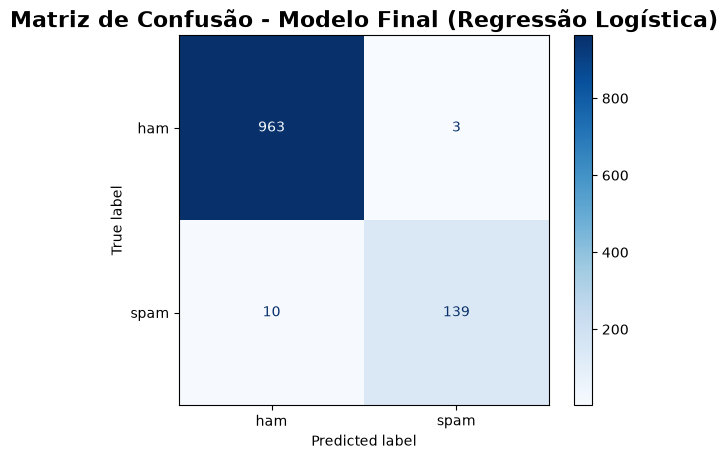

In [46]:
ConfusionMatrixDisplay.from_predictions(y_teste, previsao_final, cmap="Blues")
plt.title("Matriz de Confusão - Modelo Final (Regressão Logística)", fontsize=16, fontweight="bold")
plt.show()

# 8. Persistência do Modelo Final

In [47]:
import joblib

joblib.dump(modelo_final, "../models/modelo_bow_ngram_final.pkl")

print("Modelo Salvo com Sucesso")

Modelo Salvo com Sucesso
